# Experiment No. 8

# Comparison of Different Classification Algorithms Using Precision, Recall and Accuracy

## Aim

To implement and compare multiple **classification algorithms** on the Iris dataset and evaluate their performance using **Precision, Recall, and Accuracy**.

## Objectives

1. Understand different machine learning classification algorithms.
2. Apply multiple classifiers to the same dataset.
3. Calculate **Precision, Recall, and Accuracy**.
4. Compare the performance of different classifiers.
5. Identify the suitable classifier based on experimental results.

## Theory

**Logistic Regression:** Uses a linear decision boundary for classification.

**Decision Tree:** Classifies data using hierarchical if-else decision rules.

**Random Forest:** Combines multiple Decision Trees to improve prediction stability.

**SVM:** Finds a decision boundary that maximizes the margin between classes.

**KNN:** Classifies a sample using the majority class of its nearest neighbours.

**Naive Bayes:** Uses Bayes' theorem with an assumption of conditional feature independence.

## Evaluation Metrics

### Accuracy

$$
Accuracy = \frac{TP+TN}{TP+TN+FP+FN}
$$

### Precision

$$
Precision = \frac{TP}{TP+FP}
$$

### Recall

$$
Recall = \frac{TP}{TP+FN}
$$

For this multiclass Iris problem, **macro averaging** is used so that each class contributes equally to the final Precision and Recall.

## Implementation

1. Import required libraries.
2. Load the Iris dataset.
3. Explore the dataset.
4. Split the data into training and testing sets.
5. Standardize features where appropriate.
6. Train multiple classification algorithms.
7. Make predictions.
8. Calculate Precision, Recall, and Accuracy.
9. Compare the classifiers.
10. Analyze the results.

# Step 1 - Import Required Libraries

The required Python and Scikit-learn libraries are imported for data processing, classification, visualization, and model evaluation.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

print("Libraries imported successfully!")

Libraries imported successfully!


# Step 2 - Load the Iris Dataset

The Iris dataset contains measurements of flowers belonging to three species:

- Setosa
- Versicolor
- Virginica

The goal is to classify the flowers into their correct species.

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Iris dataset loaded successfully!")

Iris dataset loaded successfully!


# Step 3 - Create a DataFrame

The dataset is converted into a Pandas DataFrame to make data inspection and analysis easier.

In [3]:
data = pd.DataFrame(
    X,
    columns=iris.feature_names
)

data["species"] = [
    iris.target_names[i]
    for i in y
]

data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Step 4 - Check Dataset Shape

We check the number of samples and features in the dataset.

In [4]:
print("Number of samples:", data.shape[0])
print("Number of features:", len(iris.feature_names))

Number of samples: 150
Number of features: 4


# Step 5 - Display Dataset Information

The `info()` function shows the column names, data types, and number of non-null values.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


# Step 6 - Check Missing Values

Missing values can affect machine learning models, so we check whether any values are missing.

In [6]:
print("Missing values:")
print(data.isnull().sum())

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


# Step 7 - Statistical Summary

The `describe()` function provides basic statistical information about the numerical features.

In [7]:
data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Step 8 - Check Class Distribution

We count the number of samples belonging to each Iris species.

This helps determine whether the classes are balanced.

In [8]:
print("Class Distribution:")
print(data["species"].value_counts())

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Step 9 - Visualize Class Distribution

A count plot is used to visualize the number of samples belonging to each class.

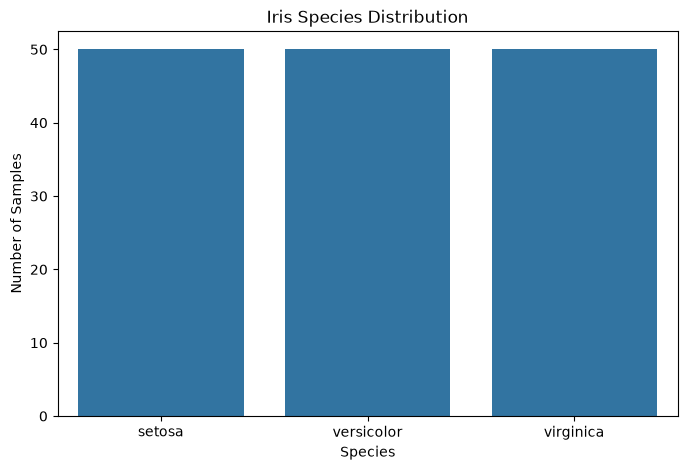

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="species"
)

plt.title("Iris Species Distribution")
plt.xlabel("Species")
plt.ylabel("Number of Samples")

plt.show()

# Step 10 - Visualize Feature Relationships

A pair plot shows relationships between the numerical features and helps us visually examine class separation.

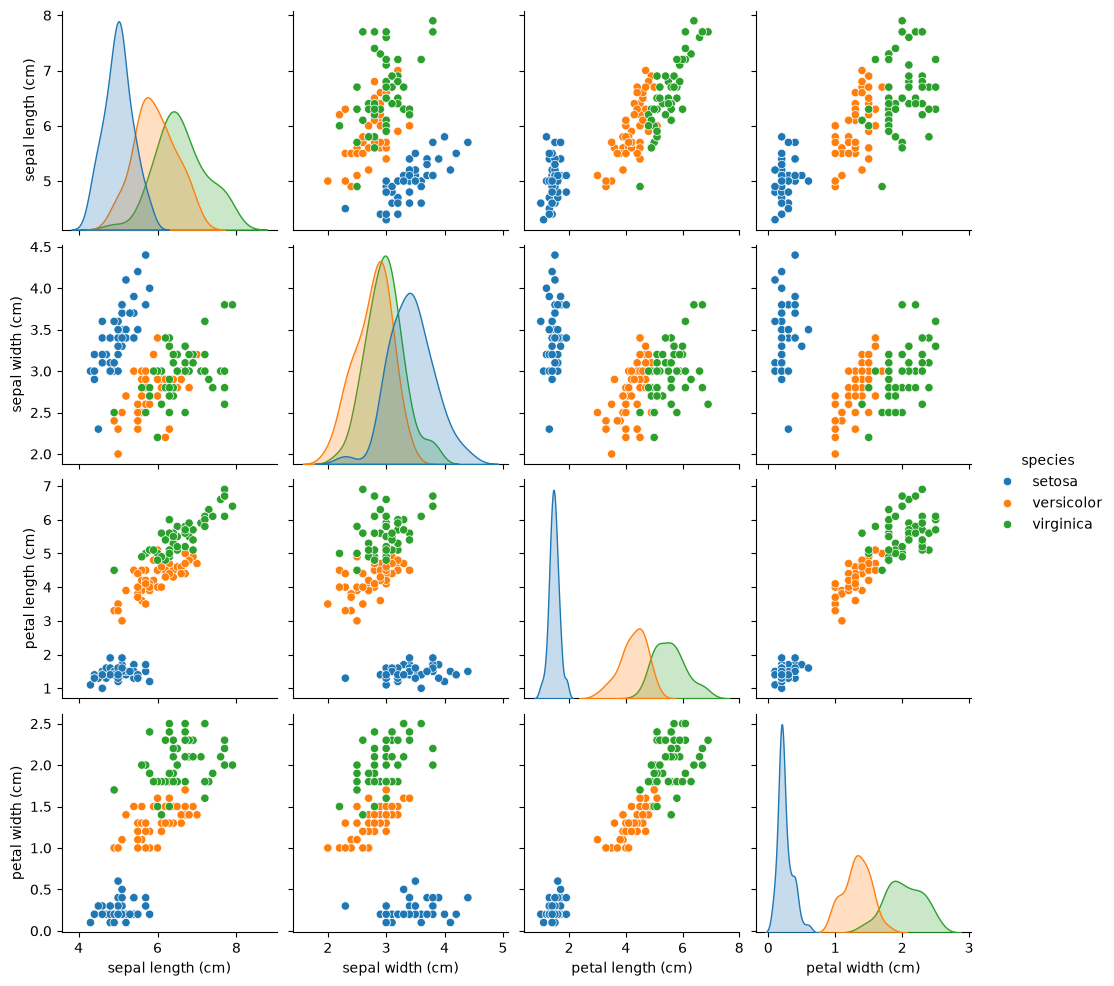

In [10]:
sns.pairplot(
    data,
    hue="species"
)

plt.show()

# Step 11 - Correlation Analysis

A correlation heatmap shows the relationships between the numerical features.

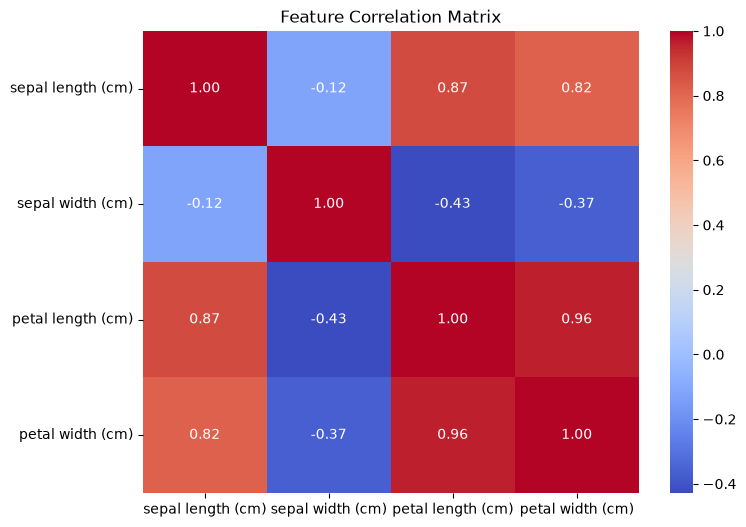

In [11]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    data.drop(columns=["species"]).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

# Step 12 - Separate Features and Target

The four flower measurements are used as input features, while the species is the target variable.

In [12]:
X = data.drop(columns=["species"])
y = data["species"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


# Step 13 - Split Dataset into Training and Testing Sets

The dataset is divided into:

- **80% training data**
- **20% testing data**

Stratification is used to maintain similar class proportions in both sets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


# Step 14 - Standardize Features

Feature scaling is important for algorithms such as **Logistic Regression, SVM, and KNN** because they can be affected by feature magnitudes.

The scaler is fitted only on training data.

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


# Step 15 - Define Classification Models

Six classification algorithms are created:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. SVM
5. KNN
6. Naive Bayes

In [15]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB()
}

print("All classification models created.")

All classification models created.


# Step 16 - Train Logistic Regression

Logistic Regression is trained using the standardized training data.

In [16]:
logistic_model = models["Logistic Regression"]

logistic_model.fit(
    X_train_scaled,
    y_train
)

y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


# Step 17 - Train Decision Tree

Decision Tree classification uses feature-based decision rules to divide the data into classes.

Feature scaling is not required for Decision Trees.

In [17]:
decision_tree_model = models["Decision Tree"]

decision_tree_model.fit(
    X_train,
    y_train
)

y_pred_tree = decision_tree_model.predict(
    X_test
)

print("Decision Tree training completed.")

Decision Tree training completed.


# Step 18 - Train Random Forest

Random Forest combines multiple Decision Trees and combines their predictions to produce the final classification.

In [18]:
random_forest_model = models["Random Forest"]

random_forest_model.fit(
    X_train,
    y_train
)

y_pred_forest = random_forest_model.predict(
    X_test
)

print("Random Forest training completed.")

Random Forest training completed.


# Step 19 - Train Support Vector Machine

SVM attempts to find a decision boundary that separates classes while maximizing the margin.

The RBF kernel is used for this experiment.

In [19]:
svm_model = models["SVM"]

svm_model.fit(
    X_train_scaled,
    y_train
)

y_pred_svm = svm_model.predict(
    X_test_scaled
)

print("SVM training completed.")

SVM training completed.


# Step 20 - Train K-Nearest Neighbour

KNN predicts a class based on the majority class among the nearest training samples.

Here, **K = 5** is used.

In [20]:
knn_model = models["KNN"]

knn_model.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn_model.predict(
    X_test_scaled
)

print("KNN training completed.")

KNN training completed.


# Step 21 - Train Naive Bayes

Gaussian Naive Bayes applies Bayes' theorem and assumes conditional independence between features.

In [21]:
naive_bayes_model = models["Naive Bayes"]

naive_bayes_model.fit(
    X_train_scaled,
    y_train
)

y_pred_nb = naive_bayes_model.predict(
    X_test_scaled
)

print("Naive Bayes training completed.")

Naive Bayes training completed.


# Step 22 - Calculate Accuracy

Accuracy measures the proportion of correctly classified samples.

$$
Accuracy =
\frac{Correct\ Predictions}
{Total\ Predictions}
$$

In [22]:
predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb
}

accuracy_results = {}

for name, predictions_model in predictions.items():

    accuracy_results[name] = accuracy_score(
        y_test,
        predictions_model
    )

for name, score in accuracy_results.items():

    print(
        f"{name}: {score:.4f}"
    )

Logistic Regression: 0.9333
Decision Tree: 0.9333
Random Forest: 0.9000
SVM: 0.9667
KNN: 0.9333
Naive Bayes: 0.9667


# Step 23 - Calculate Precision and Recall

Because Iris is a multiclass classification problem, **macro averaging** is used.

Macro averaging calculates the metric separately for each class and then gives equal importance to every class.

In [23]:
results = []

for name, predictions_model in predictions.items():

    accuracy = accuracy_score(
        y_test,
        predictions_model
    )

    precision = precision_score(
        y_test,
        predictions_model,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions_model,
        average="macro",
        zero_division=0
    )

    results.append([
        name,
        precision,
        recall,
        accuracy
    ])

print("Metrics calculated successfully.")

Metrics calculated successfully.


# Step 24 - Create Model Comparison Table

The Precision, Recall, and Accuracy values of all classifiers are organized into a DataFrame for easy comparison.

In [24]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Precision",
        "Recall",
        "Accuracy"
    ]
)

results_df = results_df.round(4)

results_df

,Algorithm,Precision,Recall,Accuracy
0,Logistic Regression,0.9333,0.9333,0.9333
1,Decision Tree,0.9333,0.9333,0.9333
2,Random Forest,0.9024,0.9000,0.9000
3,SVM,0.9697,0.9667,0.9667
4,KNN,0.9444,0.9333,0.9333
5,Naive Bayes,0.9697,0.9667,0.9667


# Step 25 - Display Results as Percentages

The evaluation metrics are converted into percentages to make the comparison easier to interpret.

In [25]:
percentage_results = results_df.copy()

for column in [
    "Precision",
    "Recall",
    "Accuracy"
]:
    percentage_results[column] = (
        percentage_results[column] * 100
    ).round(2)

percentage_results

,Algorithm,Precision,Recall,Accuracy
0,Logistic Regression,93.33,93.33,93.33
1,Decision Tree,93.33,93.33,93.33
2,Random Forest,90.24,90.00,90.00
3,SVM,96.97,96.67,96.67
4,KNN,94.44,93.33,93.33
5,Naive Bayes,96.97,96.67,96.67


# Step 26 - Compare Accuracy

A bar chart is used to compare the accuracy of all classification algorithms.

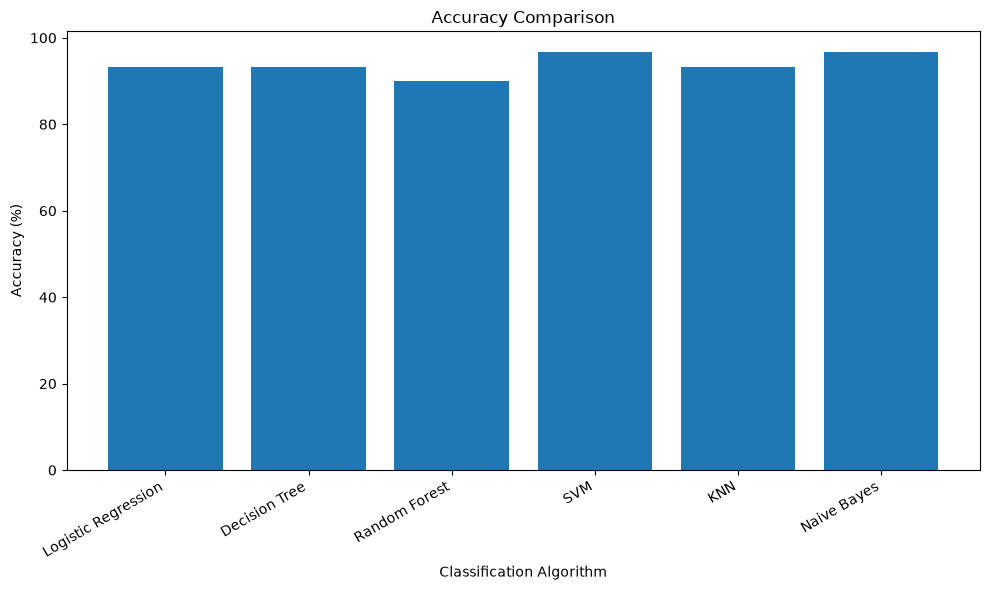

In [26]:
plt.figure(figsize=(10, 6))

plt.bar(
    percentage_results["Algorithm"],
    percentage_results["Accuracy"]
)

plt.title("Accuracy Comparison")
plt.xlabel("Classification Algorithm")
plt.ylabel("Accuracy (%)")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

# Step 27 - Compare Precision and Recall

Precision and Recall are plotted together to compare how the classifiers perform across these two metrics.

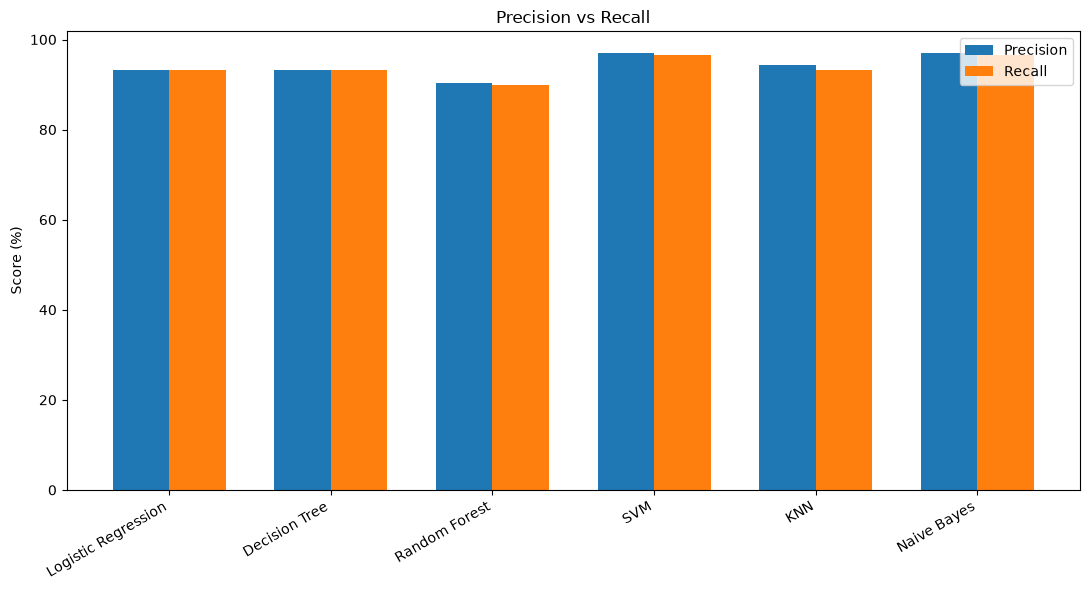

In [27]:
x = np.arange(
    len(percentage_results["Algorithm"])
)

width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    percentage_results["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x + width / 2,
    percentage_results["Recall"],
    width,
    label="Recall"
)

plt.xticks(
    x,
    percentage_results["Algorithm"],
    rotation=30,
    ha="right"
)

plt.ylabel("Score (%)")
plt.title("Precision vs Recall")
plt.legend()

plt.tight_layout()
plt.show()

# Step 28 - Generate Confusion Matrices

A confusion matrix shows the actual classes against the predicted classes.

The diagonal values represent correctly classified samples.

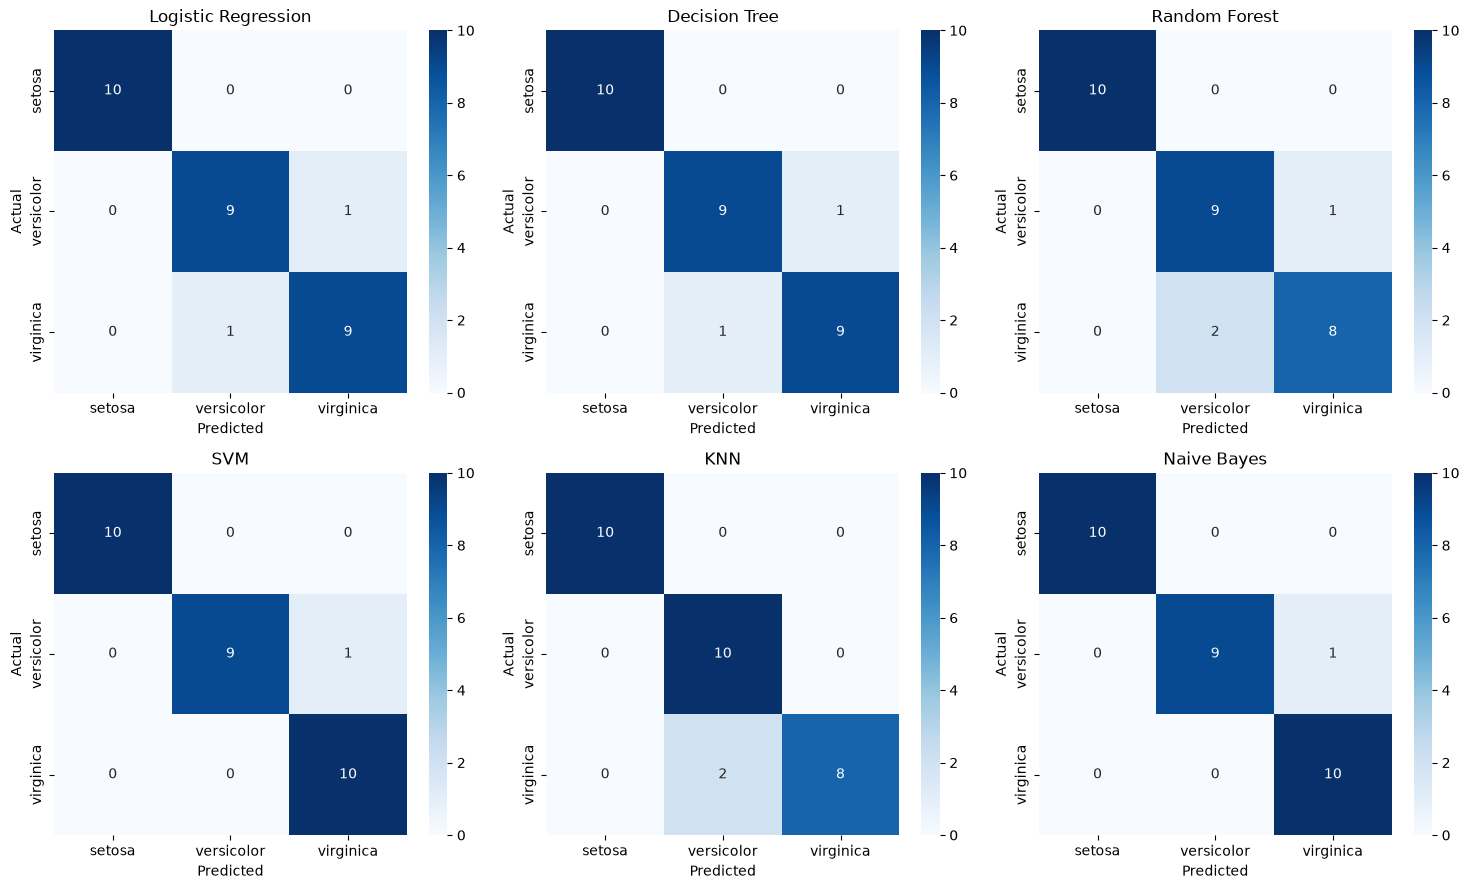

In [28]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

for ax, (name, predictions_model) in zip(
    axes.ravel(),
    predictions.items()
):

    cm = confusion_matrix(
        y_test,
        predictions_model
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=iris.target_names,
        yticklabels=iris.target_names,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


# Step 29 - Detailed Evaluation

Classification reports provide Precision, Recall, F1-score, and support for every class.

We also perform 5-fold cross-validation to obtain an additional estimate of model performance.

In [29]:
print("=" * 70)

for name, predictions_model in predictions.items():

    print(f"\n{name}")
    print("-" * 70)

    print(
        classification_report(
            y_test,
            predictions_model,
            target_names=iris.target_names,
            zero_division=0
        )
    )


print("\n5-Fold Cross-Validation Accuracy")
print("=" * 70)

cv_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf"
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB()
}

for name, model in cv_models.items():

    # Use scaled data for distance/scale-sensitive models
    if name in [
        "Logistic Regression",
        "SVM",
        "KNN",
        "Naive Bayes"
    ]:
        X_cv = StandardScaler().fit_transform(X)
    else:
        X_cv = X

    scores = cross_val_score(
        model,
        X_cv,
        y,
        cv=5,
        scoring="accuracy"
    )

    print(
        f"{name}: {scores.mean():.4f}"
    )


Logistic Regression
----------------------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Decision Tree
----------------------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Random Forest
---------------------------------------------

# Step 30 - Final Comparison and New Sample Prediction

The final comparison identifies the classifier with the highest **test Accuracy** in this experiment.

A new Iris flower sample is then classified using all six trained models.

In [30]:
# Identify model with highest test accuracy
best_model_row = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("Best Model Based on Test Accuracy:")
print(
    best_model_row["Algorithm"]
)

print(
    "\nAccuracy:",
    round(
        best_model_row["Accuracy"] * 100,
        2
    ),
    "%"
)

# New Iris flower sample
new_sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names
)

# Predictions
new_sample_scaled = scaler.transform(
    new_sample
)

print("\nNew Iris Flower:")
print(new_sample)

print("\nPredictions:")

print(
    "Logistic Regression:",
    logistic_model.predict(new_sample_scaled)[0]
)

print(
    "Decision Tree:",
    decision_tree_model.predict(new_sample)[0]
)

print(
    "Random Forest:",
    random_forest_model.predict(new_sample)[0]
)

print(
    "SVM:",
    svm_model.predict(new_sample_scaled)[0]
)

print(
    "KNN:",
    knn_model.predict(new_sample_scaled)[0]
)

print(
    "Naive Bayes:",
    naive_bayes_model.predict(new_sample_scaled)[0]
)

Best Model Based on Test Accuracy:
SVM

Accuracy: 96.67 %

New Iris Flower:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2

Predictions:
Logistic Regression: setosa
Decision Tree: setosa
Random Forest: setosa
SVM: setosa
KNN: setosa
Naive Bayes: setosa


# 📊 Final Results

Six classification algorithms were implemented and compared:

- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- KNN
- Naive Bayes

The models were evaluated using:

- **Precision**
- **Recall**
- **Accuracy**

Confusion matrices and classification reports were also generated.

The actual metric values obtained from the notebook should be used for the final comparison.

# Conclusion

In this experiment, multiple classification algorithms were successfully implemented on the **Iris dataset**.

The algorithms included **Logistic Regression, Decision Tree, Random Forest, SVM, KNN, and Naive Bayes**.

Their performance was evaluated using **Precision, Recall, and Accuracy**. Confusion matrices and classification reports were also used for detailed analysis.

The experiment demonstrated that different classification algorithms can produce different results depending on the characteristics of the dataset.

Therefore, the most suitable algorithm should be selected based on the **actual evaluation metrics and requirements of the classification problem**, rather than assuming that one algorithm is always the best.